# Load Data

In [2]:
import sys
import statsmodels.formula.api as smf
from IPython.display import HTML
import numpy as np
import pandas as pd
import gc
from stargazer.stargazer import Stargazer
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

In [3]:
required_columns = [
    'questionFeNumHelped',
    'numHelped',
    'phase',
    'hasAnswer',
    'userId',
    'year',
    'userFeNumHelped',
    'timeSinceFirstActivityDays',
    'numHelpProvidedAT',
    'numQuestionsAskedAT',
    'responseTimeHours',
    'hasSelfAnswer',
    'numQuestionsAsked30D',
    'numHelpProvided30D',
    'numQuestionsAsked7D',
    'numHelpProvided7D',
    'autobiography_active_phase_one_start'
]

bucket_labels = [
    "< 1 Week", 
    "1 Week - 1 Month", 
    "1 - 6 Months", 
    "6 - 12 Months", 
    "1 - 3 Years", 
    "3 - 6 Years", 
    "> 6 Years"
]

def create_tenure_buckets(df):
    # Define the bin edges in days
    # 1 week = 7 days
    # 1 month ≈ 30 days
    # 6 months ≈ 180 days
    # 1 year = 365 days
    # 3 years = 1095 days
    # 6 years = 2190 days
    bins = [
        -np.inf, 7, 30, 180, 365, 
        1095, 2190, np.inf
    ]
    
    # Create the new column
    df['tenure_bucket'] = pd.cut(
        df['timeSinceFirstActivityDays'], 
        bins=bins, 
        labels=bucket_labels, 
        right=True # Includes the upper edge (e.g., exactly 7 days goes into "< 1 Week")
    )
    
    return df

In [3]:
df = pd.read_parquet('../data/study_datasets/question_centered_model_7d_processed.parquet', columns=required_columns)

print(df.columns)

df['logtimeSinceFirstActivityDays'] = np.log(df['timeSinceFirstActivityDays'] + 1)
df['logNumHelpProvidedAT'] = np.log(df['numHelpProvidedAT'] + 1)
df['logNumQuestionsAskedAT'] = np.log(df['numQuestionsAskedAT'] + 1)
df['responseTimeDays'] = df['responseTimeHours'] / 24
df.loc[df['responseTimeDays'] > 7, 'hasAnswer'] = 0

# Exclude self answers
initial_rows = len(df)
df = df[df['hasSelfAnswer'] == 0].reset_index(drop=True)
rows_dropped = initial_rows - len(df)
print(f"Rows dropped because of self answers: {rows_dropped}")

df['userFeNumHelped'] = df.groupby("userId")["numHelped"].transform(lambda x: x - x.mean())

Index(['questionFeNumHelped', 'numHelped', 'phase', 'hasAnswer', 'userId',
       'year', 'userFeNumHelped', 'timeSinceFirstActivityDays',
       'numHelpProvidedAT', 'numQuestionsAskedAT', 'responseTimeHours',
       'hasSelfAnswer', 'numQuestionsAsked30D', 'numHelpProvided30D',
       'numQuestionsAsked7D', 'numHelpProvided7D',
       'autobiography_active_phase_one_start'],
      dtype='object')
Rows dropped because of self answers: 5342242


IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


In [4]:
# Apply to your dataframe
df = create_tenure_buckets(df)

# Check the distribution
print(df['tenure_bucket'].value_counts().sort_index())

tenure_bucket
< 1 Week            11156054
1 Week - 1 Month     2102372
1 - 6 Months         6045260
6 - 12 Months        4455066
1 - 3 Years          9435988
3 - 6 Years          5675148
> 6 Years            3196970
Name: count, dtype: int64


# Get Descriptives

In [5]:
# Define columns for descriptive statistics
descriptive_columns = [
    'numHelped',
    'hasAnswer',
    'numHelpProvidedAT',
    'numQuestionsAskedAT',
    'logNumHelpProvidedAT',
    'logNumQuestionsAskedAT',
    'timeSinceFirstActivityDays',
    'autobiography_active_phase_one_start',
    'responseTimeDays'
]

def calculate_grouped_descriptives(data, group_cols, columns):
    """
    Calculate descriptive statistics (μ, σ, min, max) for specified columns,
    grouped by group_cols (e.g., phase and hasAnswer)
    """
    results = []
    grouped = data.groupby(group_cols)
    
    for group_keys, group_df in grouped:
        row = dict(zip(group_cols, group_keys))
        for col in columns:
            if col in group_df.columns:
                if pd.api.types.is_numeric_dtype(group_df[col]):
                    row.update({
                        f"{col} μ": group_df[col].mean(),
                        f"{col} σ": group_df[col].std(),
                        f"{col} min": group_df[col].min(),
                        f"{col} max": group_df[col].max()
                    })
        results.append(row)
        
    return pd.DataFrame(results)

# Calculate descriptives grouped by phase and hasAnswer
print("=== DESCRIPTIVES BY PHASE AND hasAnswer ===")
grouped_stats = calculate_grouped_descriptives(df, ['phase'], descriptive_columns)
# Optionally round for readability
print(grouped_stats.round(4))

=== DESCRIPTIVES BY PHASE AND hasAnswer ===
   phase  numHelped μ  numHelped σ  numHelped min  numHelped max  hasAnswer μ  \
0      1       0.2439       1.8943              0            238        0.761   
1      2       0.2743       1.9265              0            203        0.761   

   hasAnswer σ  hasAnswer min  hasAnswer max  numHelpProvidedAT μ  ...  \
0       0.4265              0              1              16.1047  ...   
1       0.4265              0              1              16.1047  ...   

   timeSinceFirstActivityDays min  timeSinceFirstActivityDays max  \
0                             0.0                       6036.5608   
1                             0.0                       6036.5608   

   autobiography_active_phase_one_start μ  \
0                                  0.1796   
1                                  0.1796   

   autobiography_active_phase_one_start σ  \
0                                  0.3839   
1                                  0.3839   

   autobi

In [6]:
print(len(df))
# Number of unique users (excluding NaN user_id)
total_users = df['userId'].nunique(dropna=True)

print(f"Unique user_id: {total_users}")

42066858
Unique user_id: 4764048


In [9]:
# --- Helper Classes for Lightweight Caching ---
class CachedResult:
    """
    A tiny wrapper that mimics a Statsmodels result object.
    Stores params, pvalues, summary text, and the covariance matrix.
    """
    def __init__(self, model_res):
        # 1. Copy key statistics
        self.params = model_res.params
        self.pvalues = model_res.pvalues
        self.bse = model_res.bse
        self.tvalues = getattr(model_res, 'tvalues', None)
        self.rsquared = getattr(model_res, 'rsquared', None)
        self.nobs = getattr(model_res, 'nobs', None)
        
        # 2. Store Covariance Matrix (small KxK dataframe/array)
        self._cov_params = model_res.cov_params()
        
        # 3. Store the summary text internally
        self._summary_text = model_res.summary().as_text()

    def summary(self):
        """Returns a wrapper so .as_text() can still be called."""
        return self._summary_text

    def cov_params(self):
        """Returns the stored covariance matrix."""
        return self._cov_params

# --- Configuration ---
CACHE_DIR = "model_cache"

# --- Setup Cache Directory ---
if not os.path.exists(CACHE_DIR):
    try:
        os.makedirs(CACHE_DIR)
        print(f"ℹ Created cache directory: {CACHE_DIR}/")
    except Exception as e:
        print(f"⚠ Could not create cache directory: {e}")

def get_model_path(model_name):
    """Generates a safe file path for a specific model."""
    safe_name = "".join([c if c.isalnum() else "_" for c in model_name])
    return os.path.join(CACHE_DIR, f"{safe_name}.pkl")

def fit_model(formula, model_name, data, use_cache=True):
    """
    Fits a model, prints the summary, and persistently caches a lightweight
    proxy of the model object to disk.
    """
    model_path = get_model_path(model_name)

    # 1. Check Cache (Disk)
    if use_cache and os.path.exists(model_path):
        print(f"✓ Model '{model_name}' found in cache. Loading...")
        try:
            with open(model_path, 'rb') as f:
                # This loads the tiny CachedResult object
                model_proxy = pickle.load(f)
            
            # Print the summary from the loaded proxy
            print(model_proxy.summary().as_text())
            return model_proxy
            
        except Exception as e:
            print(f"⚠ Found cache file but could not load it: {e}")
            # If load fails, we proceed to re-fit below

    print(f"Fitting Model {model_name}...")
    print(f"Formula: {formula}")

    try:
        # Clear memory before fitting
        gc.collect()

        # 2. Fit the model
        model = smf.ols(formula=formula, data=data).fit(
            cov_type='cluster',
            cov_kwds={'groups': data['userId']}
        )
        
        # 3. Get Summary Text
        summary_text = model.summary().as_text()
        
        # 4. Print Summary
        print(summary_text)

        # 5. Save ONLY the lightweight proxy to disk
        # We wrap the heavy model in our light class, which now grabs cov_params()
        proxy = CachedResult(model)
        del model
        
        try:
            with open(model_path, 'wb') as f:
                pickle.dump(proxy, f)
        except Exception as e:
            print(f"⚠ Error saving individual model to disk: {e}")
        
        return proxy

    except MemoryError as e:
        print(f"✗ Memory error fitting model {model_name}: {str(e)}")
        gc.collect()
        return None
    except Exception as e:
        print(f"✗ Error fitting model {model_name}: {str(e)}")
        gc.collect()
        return None

## 1. Main Reciprocity Effect

In [7]:
# Non-FE Models
formula1 = "numHelped ~ C(phase)*C(hasAnswer) + tenure_bucket + logNumQuestionsAskedAT + logNumHelpProvidedAT + C(year)"
formula2 = "numHelped ~ C(phase)*C(hasAnswer) * tenure_bucket + logNumHelpProvidedAT + logNumQuestionsAskedAT  + C(year)"

# User FE Models
formula3 = "userFeNumHelped ~ C(phase)*C(hasAnswer) + tenure_bucket + logNumQuestionsAskedAT + logNumHelpProvidedAT + C(year)"
formula4 = "userFeNumHelped ~ C(phase)*C(hasAnswer) * tenure_bucket + logNumHelpProvidedAT + logNumQuestionsAskedAT  + C(year)"

# Question FE Models
formula5 = "questionFeNumHelped ~ C(phase)*C(hasAnswer) + tenure_bucket + logNumQuestionsAskedAT + logNumHelpProvidedAT + C(year)"
formula6 = "questionFeNumHelped ~ C(phase)*C(hasAnswer) * tenure_bucket + logNumHelpProvidedAT + logNumQuestionsAskedAT  + C(year)"

model_names = ["1", "2", "3", "4", "5", "6"]
formulas = [formula1, formula2, formula5, formula6]

In [19]:
successful_models = []

for i, (formula, name) in enumerate(zip(formulas, model_names)):
    print(f"Processing {i+1}/{len(formulas)}")
    result = fit_model(formula, name, df)
    if result:
        successful_models.append(name)

Processing 1/6
Fitting Model 1...
Formula: numHelped ~ C(phase)*C(hasAnswer) + tenure_bucket + logNumQuestionsAskedAT + logNumHelpProvidedAT + C(year)
                            OLS Regression Results                            
Dep. Variable:              numHelped   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     758.3
Date:                Wed, 31 Dec 2025   Prob (F-statistic):               0.00
Time:                        03:18:02   Log-Likelihood:            -8.5110e+07
No. Observations:            42066858   AIC:                         1.702e+08
Df Residuals:                42066829   BIC:                         1.702e+08
Df Model:                          28                                         
Covariance Type:              cluster                                         
                                        coef    std err    

## 2. Models with Matched Data

In [4]:
matched_df = pd.read_parquet('../data/study_datasets/question_centered_model_7d_matched.parquet', columns=required_columns)

matched_df['logtimeSinceFirstActivityDays'] = np.log(matched_df['timeSinceFirstActivityDays'] + 1)
matched_df['logNumHelpProvidedAT'] = np.log(matched_df['numHelpProvidedAT'] + 1)
matched_df['logNumQuestionsAskedAT'] = np.log(matched_df['numQuestionsAskedAT'] + 1)

# matched_df['userFeNumHelped'] = matched_df.groupby("userId")["numHelped"].transform(lambda x: x - x.mean())

In [5]:
matched_df = create_tenure_buckets(matched_df)

In [10]:
# --- Run Analysis ---
for i, (formula, name) in enumerate(zip(formulas, model_names)):
    print(f"Processing Matched Model {i+1}/{len(formulas)}")
    # We append "_matched" to the name to distinguish in Stargazer
    fit_model(formula, name + "_matched", matched_df)

Processing Matched Model 1/4
Fitting Model 1_matched...
Formula: numHelped ~ C(phase)*C(hasAnswer) + tenure_bucket + logNumQuestionsAskedAT + logNumHelpProvidedAT + C(year)
                            OLS Regression Results                            
Dep. Variable:              numHelped   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     386.3
Date:                Fri, 09 Jan 2026   Prob (F-statistic):               0.00
Time:                        08:47:04   Log-Likelihood:            -1.3049e+08
No. Observations:            63557320   AIC:                         2.610e+08
Df Residuals:                63557291   BIC:                         2.610e+08
Df Model:                          28                                         
Covariance Type:              cluster                                         
                                     

In [11]:
model = fit_model(formula6, "4_matched", matched_df)

✓ Model '4_matched' found in cache. Loading...
⚠ Found cache file but could not load it: 'str' object has no attribute 'as_text'
Fitting Model 4_matched...
Formula: questionFeNumHelped ~ C(phase)*C(hasAnswer) * tenure_bucket + logNumHelpProvidedAT + logNumQuestionsAskedAT  + C(year)
                             OLS Regression Results                            
Dep. Variable:     questionFeNumHelped   R-squared:                       0.001
Model:                             OLS   Adj. R-squared:                  0.001
Method:                  Least Squares   F-statistic:                     111.5
Date:                 Fri, 09 Jan 2026   Prob (F-statistic):               0.00
Time:                         09:55:22   Log-Likelihood:            -7.2226e+07
No. Observations:             63557320   AIC:                         1.445e+08
Df Residuals:                 63557273   BIC:                         1.445e+08
Df Model:                           46                                      

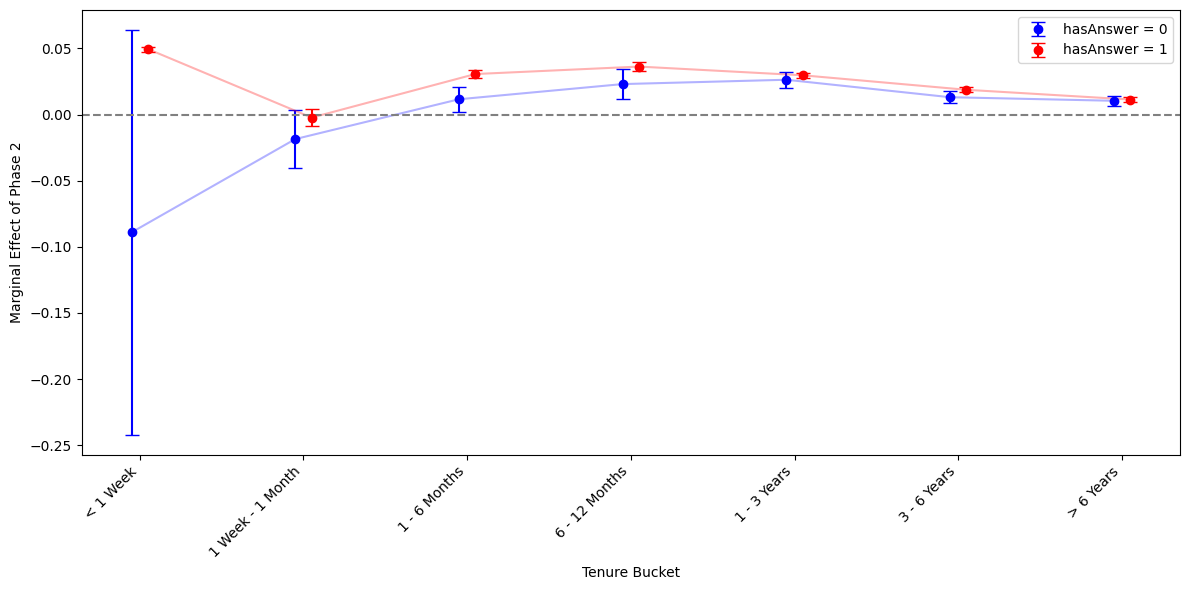

In [12]:
# ---------------------------------------------------------
# 2. Extract Coefficients and Calculate Effects
# ---------------------------------------------------------
# Assuming 'model' is already fitted
params = model.params
cov = model.cov_params()
results = []

for ha in [0, 1]:
    # Iterate through the explicit label list to ensure correct order
    for t_level in bucket_labels:
        contrast = pd.Series(0.0, index=params.index)
        
        # A. Base Effect of Phase 2
        if 'C(phase)[T.2]' in contrast.index:
            contrast['C(phase)[T.2]'] = 1.0
            
        # B. Interaction: Phase 2 * HasAnswer (only if hasAnswer=1)
        if ha == 1:
            term = 'C(phase)[T.2]:C(hasAnswer)[T.1]'
            term_flipped = 'C(hasAnswer)[T.1]:C(phase)[T.2]'
            if term in contrast.index: contrast[term] = 1.0
            elif term_flipped in contrast.index: contrast[term_flipped] = 1.0
        
        # C. Interaction: Phase 2 * Tenure Bucket
        # We need the term specific to this bucket level. 
        # Note: The reference bucket (usually "< 1 Week") won't have a term.
        found_interaction = False
        for p_name in contrast.index:
            # Look for interaction containing Phase 2 AND this specific Label 
            # AND NOT containing "hasAnswer" (to avoid the 3-way term)
            if 'C(phase)[T.2]' in p_name and t_level in p_name and 'hasAnswer' not in p_name:
                contrast[p_name] = 1.0
                break
        
        # D. Three-way Interaction: Phase 2 * HasAnswer * Tenure Bucket
        if ha == 1:
            for p_name in contrast.index:
                if 'C(phase)[T.2]' in p_name and 'C(hasAnswer)[T.1]' in p_name and t_level in p_name:
                    contrast[p_name] = 1.0
                    break
        
        est = np.dot(contrast, params)
        var = np.dot(contrast, np.dot(cov, contrast))
        se = np.sqrt(var)
        
        results.append({
            'hasAnswer': ha,
            'tenure_bucket': t_level,
            'effect': est,
            'se': se
        })

res_df = pd.DataFrame(results)

# ---------------------------------------------------------
# 3. Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

x_mapping = {label: i for i, label in enumerate(bucket_labels)}
colors = {0: 'blue', 1: 'red'}
labels_legend = {0: 'hasAnswer = 0', 1: 'hasAnswer = 1'}

for ha in [0, 1]:
    subset = res_df[res_df['hasAnswer'] == ha].copy()
    # Offset x-position slightly
    subset['x_pos'] = subset['tenure_bucket'].map(x_mapping) + (0.05 if ha == 1 else -0.05)
    
    ax.errorbar(
        subset['x_pos'], 
        subset['effect'], 
        yerr=1.96 * subset['se'], 
        fmt='o', 
        color=colors[ha],
        label=labels_legend[ha],
        capsize=5
    )
    # Connect lines
    ax.plot(subset['x_pos'], subset['effect'], color=colors[ha], alpha=0.3)

# Set X-ticks using the ordered list
ax.set_xticks(range(len(bucket_labels)))
ax.set_xticklabels(bucket_labels, rotation=45, ha='right')

ax.set_xlabel('Tenure Bucket')
ax.set_ylabel('Marginal Effect of Phase 2')
ax.axhline(0, color='gray', linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

In [1]:
def visualize_phase_answer_interaction(model, bucket_labels):
    """
    Visualizes the interaction effect (Difference-in-Differences) of 
    Phase 2 and HasAnswer across tenure buckets.
    
    Interaction = (Phase2|HasAnswer=1) - (Phase2|HasAnswer=0)
    
    Parameters:
    - model: The fitted statsmodels object
    - bucket_labels: List of tenure bucket labels in the desired order
    """
    params = model.params
    cov = model.cov_params()
    results = []
    
    # Common terms to look for (Phase 2 : HasAnswer 1)
    # Note: Statsmodels might vary order, e.g., C(hasAnswer):C(phase)
    base_terms = [
        'C(phase)[T.2]:C(hasAnswer)[T.1]',
        'C(hasAnswer)[T.1]:C(phase)[T.2]'
    ]

    for t_level in bucket_labels:
        # Initialize contrast vector
        contrast = pd.Series(0.0, index=params.index)
        
        # 1. Base Interaction Term (Beta_PH)
        # This represents the interaction for the Reference Bucket
        base_found = False
        for term in base_terms:
            if term in contrast.index:
                contrast[term] = 1.0
                base_found = True
                break
        
        if not base_found:
            print(f"Warning: Base interaction term not found. Model might differ.")

        # 2. Three-way Interaction Term (Beta_PHT)
        # This adjusts the interaction for specific tenure buckets (relative to reference)
        # We look for a term containing Phase2, HasAnswer1, and the current Bucket Label
        
        # Statsmodels naming for the bucket usually looks like: tenure_bucket[T.Label]
        # We search robustly for a parameter containing all 3 components
        for p_name in contrast.index:
            if ('C(phase)[T.2]' in p_name and 
                'C(hasAnswer)[T.1]' in p_name and 
                t_level in p_name):
                contrast[p_name] = 1.0
                break
        
        # Calculate Estimate and SE
        est = np.dot(contrast, params)
        var = np.dot(contrast, np.dot(cov, contrast))
        se = np.sqrt(var)
        
        results.append({
            'tenure_bucket': t_level,
            'interaction_effect': est,
            'se': se,
            'lower': est - 1.96 * se,
            'upper': est + 1.96 * se
        })

    res_df = pd.DataFrame(results)

    # --- Plotting ---
    # Setup
    fig, ax = plt.subplots(figsize=(12, 6))
    x_pos = np.arange(len(res_df))
    y = res_df['interaction_effect']
    yerr = 1.96 * res_df['se']
    
    # --- Logic for Coloring ---
    # Check if the confidence interval crosses zero
    # Upper bound < 0 OR Lower bound > 0 implies significance
    is_significant = (y + yerr < 0) | (y - yerr > 0)
    colors = ['#E63946' if sig else '#A8DADC' for sig in is_significant] # Red for significant, Pale Blue for not
    
    # Plot Error bars (Uniform color for bars to keep it tidy)
    ax.errorbar(
        x_pos, y, yerr=yerr, fmt='none', 
        ecolor='#2F4F4F', alpha=0.3, elinewidth=2, capsize=0
    )
    
    # Plot Connecting Line (Subtle)
    ax.plot(x_pos, y, color='gray', alpha=0.3, linewidth=1, linestyle='--')
    
    # Plot Points (Colored by significance)
    for x, val, c in zip(x_pos, y, colors):
        ax.scatter(x, val, color=c, s=100, zorder=5, edgecolors='white', linewidth=1.5)
    
    # Formatting
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(res_df['tenure_bucket'], rotation=0)
    
    # Remove all spines for a "floating" Tufte style
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Add tick markers only on bottom
    ax.tick_params(axis='both', length=0) 
    ax.grid(axis='y', linestyle=':', alpha=0.4)
        
    plt.tight_layout()
    plt.savefig('strength_rec.pdf')
    plt.show()

    del res_df
    
# --- Usage Example ---
interaction_df = visualize_phase_answer_interaction(model, bucket_labels)

NameError: name 'model' is not defined